# regression simple

#Importing libraries

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
#import seaborn as sns
import numpy as np
data=pd.read_csv('Salary_Data.csv')

#data

In [8]:
data

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


In [10]:
data.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [11]:
#selectioner les colonnes "YearsExperience" comme variables d entree
#et la colone Salary
x=data[['YearsExperience']]
y=data['Salary']        

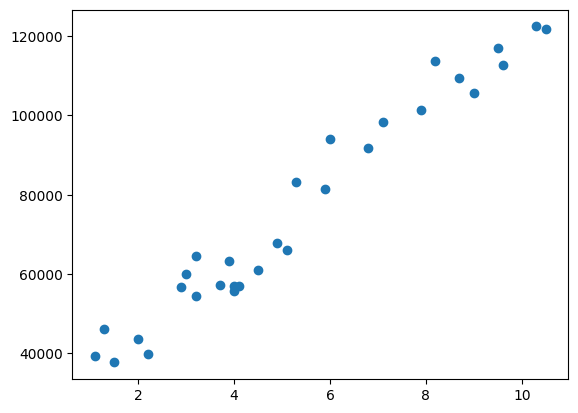

In [12]:
#metre les point sur un graphique
plt.scatter(x,y)


In [13]:
#separer la databASE en train de test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=1/3,random_state=0)

In [15]:
#importer la librairie lineare regression

from sklearn.linear_model import LinearRegression

regressor = LinearRegression()  # instancier

In [16]:
regressor.fit(x_train,y_train)#entrainement=produire l equation lineaire

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
#reteouver les coeffitions et l ordonnee a l origine
print(regressor.coef_)
print(regressor.intercept_)

[9345.94244312]
26816.192244031183


Text(0, 0.5, 'Salary')

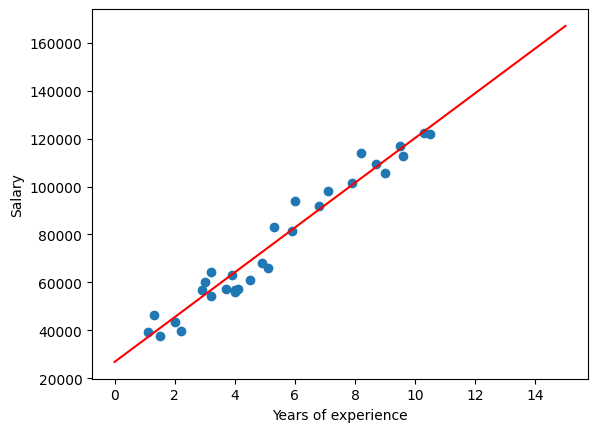

In [13]:
#ajouter sur le graphique la droite 
ordonner=np.linspace(0,15,1000)
plt.scatter(x,y)
plt.plot(ordonner,regressor.coef_[0]*ordonner+regressor.intercept_,color='r')
plt.xlabel('Years of experience')
plt.ylabel('Salary')
           


#evaluate

In [14]:
# prediction sur la base test
y_predict=regressor.predict(x_test)

In [15]:
#metrique
from sklearn import metrics
import numpy as np

print('MAE :', metrics.mean_absolute_error(y_test, y_predict))
print('MSE :', metrics.mean_squared_error(y_test, y_predict))
print('RMSE :', np.sqrt(metrics.mean_squared_error(y_test, y_predict)))
print('R² :', metrics.r2_score(y_test, y_predict))      
      
      

MAE : 3426.4269374307078
MSE : 21026037.329511296
RMSE : 4585.4157204675885
R² : 0.9749154407708353


In [16]:
import pandas as pd
NewData =[[5],[4]]
NewTest=pd.DataFrame(NewData,columns=['YearsExperience'])
y_new=regressor.predict(NewTest)
y_new

array([73545.90445964, 64199.96201652])